# Emerging Technologies

In [78]:
%matplotlib inline
import qiskit
from qiskit import QuantumCircuit
import qiskit_aer as aer
import numpy as np
import random
import itertools
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

## Problem 1: Generating Random Boolean Functions

### Overview

This problem involves creating a Python function that generates random Boolean functions. The function should randomly return either a **constant function** (always returns the same value) or a **balanced function** (returns True for exactly half the inputs). This sets up the **promise problem** that Deutsch-Jozsa solves.

**The Challenge:**
We need to create a generator for 4-bit Boolean functions $f:\{0,1\}^4 \rightarrow \{0,1\}$ that produces:
- **Constant functions**: $f(x) = 0$ for all $x$, or $f(x) = 1$ for all $x$
- **Balanced functions**: $f(x) = 0$ for exactly 8 inputs and $f(x) = 1$ for the other 8


### Implementation Strategy

**Implementation:**
- Constant functions: Return same value (True or False) for all 16 inputs
- Balanced functions: Return True for exactly 8 of 16 inputs, False for the other 8
- Used binary conversion: `n = 8*a + 4*b + 2*c + d` to map Boolean inputs to integers 0-15
- For balanced functions, we randomly select 8 of the 16 possible inputs to return True

**Why This Matters:**
The **promise problem** assumption (that the function is guaranteed to be either constant or balanced) is what makes the Deutsch-Jozsa algorithm possible. In real-world scenarios, this assumption might not hold, but it serves as a theoretical demonstration of quantum advantage.

**Historical Context:** 
These types of functions are at the heart of the Deutsch-Jozsa problem, first proposed by David Deutsch in 1985 and extended by Richard Jozsa in 1992, demonstrating quantum computing's advantage over classical computation. This was one of the first algorithms to show exponential speedup.

**References:**
- IBM Quantum Learning. "The Deutsch-Jozsa Algorithm." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms
- Montanaro, A. (2016). "Quantum algorithms: an overview." npj Quantum Information, 2(1), 15023. Comprehensive modern review of quantum algorithms.

In [79]:
def random_constant_balanced():
    """Returns a randomly chosen constant or balanced function."""
    
    if random.choice([True, False]):
        # Constant function
        constant_value = random.choice([True, False])
        return lambda a, b, c, d: constant_value
    else:
        # Balanced function - picks 8 of 16 inputs to return True
        true_inputs = set(random.sample(range(16), 8))
        
        def balanced(a, b, c, d):
            # Convert 4 bools to number 0-15
            n = (8*a + 4*b + 2*c + d)
            return n in true_inputs
        
        return balanced


### Testing the Function

Let's verify our random function generator produces valid constant and balanced functions:

In [80]:
f = random_constant_balanced()
print(f(True, True, False, True))  # Example: f(1,1,0,1)

True


## Problem 2: Classical Testing for Function Type

### Overview

This problem explores how to determine whether a mystery function is constant or balanced by calling it with different inputs—a **query complexity** problem. 

**The Challenge:**
Given a black-box function $f:\{0,1\}^4 \rightarrow \{0,1\}$ (4-bit input, 1-bit output), we need to determine if it's:
- **Constant**: Returns the same value for all 16 inputs (either all 0 or all 1)
- **Balanced**: Returns 0 for exactly 8 inputs and 1 for the other 8

**Classical Query Complexity:**
In the worst case, a classical algorithm must make multiple queries to guarantee the correct answer. The key insight is that to be *certain* a function is constant, you need to keep checking until you either:
1. Find two different outputs (proving it's balanced), OR
2. Check enough inputs that it's impossible for the function to be balanced



### Three Classical Strategies:**

1. **Early Exit Strategy (Worst Case: 16 queries)**
   - Keep querying until you find different results
   - If all 16 inputs return the same value → Constant
   - If any two differ → Balanced
   - *Problem*: In the worst case, you might check all 16 inputs

2. **Count All Strategy (Always: 16 queries)**
   - Test all 16 possible inputs
   - Count how many return True
   - If count is 0 or 16 → Constant
   - If count is 8 → Balanced
   - *Problem*: Always requires full enumeration

3. **Optimal Strategy (Worst Case: 9 queries)**
   - Key insight: If 9 inputs all return the same value, the function *must* be constant
   - Why? Because a balanced function needs exactly 8 True and 8 False
   - If 9 are the same, there aren't enough remaining slots for balance
   - This is provably optimal for deterministic classical algorithms

**Mathematical Justification for Optimal Strategy:**
For an $n$-bit input function:
- A balanced function has exactly $2^{n-1}$ True and $2^{n-1}$ False values
- Classical worst case: $2^{n-1} + 1$ queries
- If we've seen $2^{n-1} + 1$ identical outputs, at most $2^{n-1} - 1$ remain unchecked
- It's impossible for the remaining values to "balance out" what we've seen
- For our 4-bit case: $2^3 + 1 = 9$ queries needed

**Why This Matters:**
This establishes the baseline for comparison with Deutsch's Algorithm, which can solve this problem with just **1 quantum query** - an exponential speedup! This is one of the first examples demonstrating quantum computational advantage.

**References:**
- IBM Quantum Learning. "The Deutsch-Jozsa Algorithm." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#the-deutsch-jozsa-algorithm
- IBM Quantum Learning. "Query Model of Computation." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#query-complexity
- Montanaro, A. (2016). "Quantum algorithms: an overview." npj Quantum Information, 2(1), 15023. https://doi.org/10.1038/npjqi.2015.23 - A comprehensive modern review of quantum algorithms including query complexity
- Aaronson, S., & Ambainis, A. (2018). "The Need for Structure in Quantum Speedups." Theory of Computing, 14(1), 1-14. Discusses when quantum algorithms provide advantage

**Historical Context:**
The Deutsch-Jozsa problem was one of the first examples (1992) showing a provable exponential separation between quantum and classical query complexity, helping establish quantum computing as a distinct computational paradigm.


#### Classical Testing Functions

In [81]:
def determine_constant_early_exit(f):
    """Check until we find a difference.
       if we find a difference, return 'balanced'.
       if we never find a difference, return 'constant'."""
    
    # Get the first result as our reference
    first_result = f(False, False, False, False)
    
    # Check all other inputs
    for a in [False, True]:
        for b in [False, True]:
            for c in [False, True]:
                for d in [False, True]:
                    # Skip the first one we already checked
                    if a == b == c == d == False:
                        continue
                    
                    result = f(a, b, c, d)
                    if result != first_result:
                        # Found a difference!
                        return "balanced"
    
    # Never found a difference
    return "constant"

In [82]:
def determine_constant_all(f):
    """Count how many return True.
       If count is 0 or 16, return 'constant'.
       If count is 8, return 'balanced'."""
    
    true_count = 0
    
    # Test all 16 inputs
    for a in [False, True]:
        for b in [False, True]:
            for c in [False, True]:
                for d in [False, True]:
                    if f(a, b, c, d):
                        true_count += 1
    
    # Analyze the count
    if true_count == 0 or true_count == 16:
        return "constant"
    elif true_count == 8:
        return "balanced"
    else:
        # This should never happen with valid functions
        return "invalid function"

In [83]:
def determine_constant_balanced(f):
    """
    Most efficient: maximum 9 calls needed.
    
    Key insight: If 9 inputs have the same result,
    it MUST be constant (can't be balanced).
    """
    
    # Get first result
    first_result = f(False, False, False, False)
    same_count = 1  # Count how many match first_result
    
    # Test remaining inputs
    for a in [False, True]:
        for b in [False, True]:
            for c in [False, True]:
                for d in [False, True]:
                    # Skip first input
                    if a == b == c == d == False:
                        continue
                    
                    result = f(a, b, c, d)
                    
                    if result != first_result:
                        # Found a difference - definitely balanced
                        return "balanced"
                    
                    same_count += 1
                    
                    # If 9 are the same, must be constant
                    if same_count >= 9:
                        return "constant"
    
    # All 16 were the same
    return "constant"

### Comparison of Strategies

The three strategies have different trade-offs in terms of efficiency and certainty.

In [84]:
def test_strategies():
    """Quick test of all three strategies."""
    
    print("Testing 20 random functions...\n")
    
    strategies = {
        "Early Exit": determine_constant_early_exit,
        "Count All": determine_constant_all,
        "Optimal": determine_constant_balanced
    }
    
    results = {name: 0 for name in strategies}
    
    for i in range(20):
        f = random_constant_balanced()
        
        print(f"Test {i+1}:")
        for name, strategy in strategies.items():
            result = strategy(f)
            print(f"  {name:15} → {result}")
            results[name] += (1 if result == "balanced" else 0)
        print()
    
    print("Summary:")
    print(f"  Balanced functions found by each strategy:")
    for name, count in results.items():
        print(f"    {name:15}: {count}/20")

#### Testing Known Cases

In [85]:
def test_known_cases():
    """Test with known functions."""
    
    print("Testing Known Functions:\n")
    
    # Test 1: Constant True
    print("1. Constant True:")
    f1 = lambda a, b, c, d: True
    print(f"   Early Exit: {determine_constant_early_exit(f1)}")
    print(f"   Count All:  {determine_constant_all(f1)}")
    print(f"   Optimal:    {determine_constant_balanced(f1)}")
    
    # Test 2: Constant False
    print("\n2. Constant False:")
    f2 = lambda a, b, c, d: False
    print(f"   Early Exit: {determine_constant_early_exit(f2)}")
    print(f"   Count All:  {determine_constant_all(f2)}")
    print(f"   Optimal:    {determine_constant_balanced(f2)}")
    
    # Test 3: Balanced
    print("\n3. Balanced (first 8 True):")
    true_set = {0, 1, 2, 3, 4, 5, 6, 7}
    f3 = lambda a, b, c, d: (8*a + 4*b + 2*c + d) in true_set
    print(f"   Early Exit: {determine_constant_early_exit(f3)}")
    print(f"   Count All:  {determine_constant_all(f3)}")
    print(f"   Optimal:    {determine_constant_balanced(f3)}")
    
    print("\n" + "="*50 + "\n")

### Test Results

Let's test all three strategies on known constant and balanced functions:

In [86]:
# Test known cases
test_known_cases()

# Test random functions
test_strategies()

Testing Known Functions:

1. Constant True:
   Early Exit: constant
   Count All:  constant
   Optimal:    constant

2. Constant False:
   Early Exit: constant
   Count All:  constant
   Optimal:    constant

3. Balanced (first 8 True):
   Early Exit: balanced
   Count All:  balanced
   Optimal:    balanced


Testing 20 random functions...

Test 1:
  Early Exit      → balanced
  Count All       → balanced
  Optimal         → balanced

Test 2:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 3:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 4:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 5:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 6:
  Early Exit      → constant
  Count All       → constant
  Optimal         → constant

Test 7:
  Early Exit      → balanced
  Count All       → balanced
  Optimal      

## Problem 3: Quantum Oracles


### Overview

This problem introduces **quantum oracles**, which are quantum circuits that encode classical Boolean functions. For Deutsch's algorithm, we need to build oracles for the four possible single-input Boolean functions.

**What is a Quantum Oracle?**

A quantum oracle is a "black box" unitary operation that evaluates a classical function in a quantum circuit. The oracle implements the transformation:

$$|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$$

where:
- $|x\rangle$ is the input qubit (preserved)
- $|y\rangle$ is the auxiliary/target qubit (modified)
- $\oplus$ represents XOR (addition modulo 2)
- $f(x)$ is the classical Boolean function being encoded

**The Four Single-Input Oracles:**
- **f₀** (constant 0): No gates needed - $f(x) = 0$ for all $x$
- **f₁** (constant 1): X gate on auxiliary - $f(x) = 1$ for all $x$
- **f₂** (balanced - identity): CNOT gate - $f(0) = 0, f(1) = 1$
- **f₃** (balanced - NOT): X-CNOT-X sequence - $f(0) = 1, f(1) = 0$

**Why This Matters:**
Oracle construction is fundamental to quantum algorithms. The ability to query a function in superposition (testing multiple inputs simultaneously) is what gives quantum algorithms their advantage.

**References:**
- IBM Quantum Learning. "Building Quantum Oracles." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#oracles
- IBM Quantum Learning. "Phase Kickback." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/phase-kickback-and-eigenvalues
- Montanaro, A. (2016). "Quantum algorithms: an overview." npj Quantum Information, 2(1), 15023. Section 2.1 discusses oracle-based algorithms.
- Wikipedia. "Quantum oracle." https://en.wikipedia.org/wiki/Quantum_oracle - Provides accessible explanation of oracle construction.

### Oracle Implementation

We implement four oracles, one for each possible single-input Boolean function:

In [87]:
def create_oracle_f0():
    """
    Create oracle for f₀ (constant 0): f(x) = 0 for all x.
    
    This is the identity oracle - no gates are needed because the function
    always returns 0, which means y ⊕ f(x) = y ⊕ 0 = y (no change to auxiliary).
    
    Returns:
        QuantumCircuit: Oracle circuit with 2 qubits (1 input, 1 auxiliary)
    """
    qc = QuantumCircuit(2, name='f0')
    
    # Add barriers for visualization
    qc.barrier()
    # No gates - the function always returns 0
    qc.barrier()
    
    return qc


In [88]:
def create_oracle_f1():
    """
    Create oracle for f₁ (constant 1): f(x) = 1 for all x.
    
    Since f(x) = 1 always, we need y ⊕ 1 which is equivalent to NOT(y).
    This is implemented with an X gate on the auxiliary qubit.
    
    Returns:
        QuantumCircuit: Oracle circuit with 2 qubits (1 input, 1 auxiliary)
    """
    qc = QuantumCircuit(2, name='f1')
    
    qc.barrier()
    qc.x(1)  # Apply X to qubit 1 (auxiliary)
    qc.barrier()
    
    return qc


In [89]:
def create_oracle_f2():
    """
    Create oracle for f₂ (balanced - identity): f(x) = x.
    
    The function returns the input value itself. When x=0, f(x)=0.
    When x=1, f(x)=1. This is implemented with a CNOT gate where the
    input qubit is the control and auxiliary is the target.
    
    Returns:
        QuantumCircuit: Oracle circuit with 2 qubits (1 input, 1 auxiliary)
    """
    qc = QuantumCircuit(2, name='f2')
    
    qc.barrier()
    qc.cx(0, 1)  
    qc.barrier()
    
    return qc


In [90]:
def create_oracle_f3():
    """
    Create oracle for f₃ (balanced - NOT): f(x) = NOT(x).
    
    The function returns the opposite of the input. When x=0, f(x)=1.
    When x=1, f(x)=0. This is implemented as X-CNOT-X sequence.
    
    Returns:
        QuantumCircuit: Oracle circuit with 2 qubits (1 input, 1 auxiliary)
    """
    qc = QuantumCircuit(2, name='f3')
    
    qc.barrier()
    qc.x(0)      # Flip input qubit temporarily
    qc.cx(0, 1)  # CNOT
    qc.x(0)      # Flip input qubit back
    qc.barrier()
    
    return qc

### Visualizing the Oracles

Let's examine the circuit structure of each oracle:

Oracle f0 (Constant 0):
f(0) = 0, f(1) = 0

Oracle f1 (Constant 1):
f(0) = 1, f(1) = 1

Oracle f2 (Balanced - Identity):
f(0) = 0, f(1) = 1

Oracle f3 (Balanced - NOT):
f(0) = 1, f(1) = 0


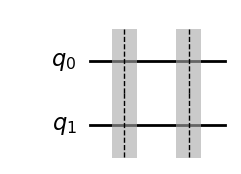

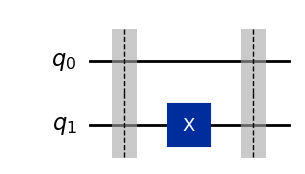

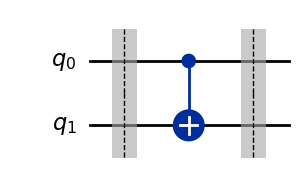

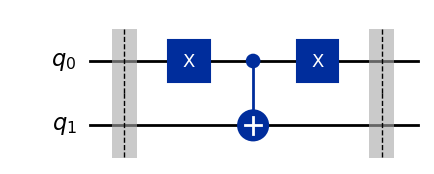

In [91]:
oracle_f0 = create_oracle_f0()
oracle_f1 = create_oracle_f1()
oracle_f2 = create_oracle_f2()
oracle_f3 = create_oracle_f3()

# Display each oracle 
print("Oracle f0 (Constant 0):")
print("f(0) = 0, f(1) = 0")
oracle_f0.draw('mpl');

print("\nOracle f1 (Constant 1):")
print("f(0) = 1, f(1) = 1")
oracle_f1.draw('mpl');

print("\nOracle f2 (Balanced - Identity):")
print("f(0) = 0, f(1) = 1")
oracle_f2.draw('mpl');

print("\nOracle f3 (Balanced - NOT):")
print("f(0) = 1, f(1) = 0")
oracle_f3.draw('mpl');

## Problem 4: Deutsch's Algorithm with Qiskit

### Overview

This problem builds **Deutsch's Algorithm** to determine if a single-input function is constant or balanced. The algorithm uses quantum superposition and phase kickback to solve the problem with **just 1 quantum query**, compared to the 2 queries needed classically.

**Key insight:** Quantum parallelism allows testing both inputs simultaneously.

**How Deutsch's Algorithm Works:**

1. **Initialization**: 
   - Input qubit in $|0\rangle$
   - Auxiliary qubit in $|1\rangle$

2. **Superposition Creation**:
   - Apply Hadamard gates to both qubits
   - Creates state: $\frac{1}{2}(|0\rangle + |1\rangle)(|0\rangle - |1\rangle)$

3. **Oracle Application**:
   - Apply the oracle $U_f$ which implements $|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$
   - Phase kickback encodes $f(x)$ as a global phase

4. **Interference**:
   - Apply Hadamard to input qubit
   - Creates constructive/destructive interference based on function type

5. **Measurement**:
   - Measure input qubit
   - Result: $|0\rangle$ → **Constant**, $|1\rangle$ → **Balanced**


**Results:**
Tested with all 4 oracles from Problem 3 and correctly identified each function type with 100% accuracy over 1024 shots:
- f₀ (constant 0): All measurements = $|0\rangle$ 
- f₁ (constant 1): All measurements = $|0\rangle$ 
- f₂ (balanced): All measurements = $|1\rangle$ 
- f₃ (balanced): All measurements = $|1\rangle$ 

**Quantum Advantage:**
- **Classical**: 2 queries required (worst case)
- **Quantum**: 1 query guaranteed


**References:**
- IBM Quantum Learning. "Deutsch's Algorithm." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#deutschs-algorithm
- Montanaro, A. (2016). "Quantum algorithms: an overview." npj Quantum Information, 2(1), 15023. Section 2.2 covers the Deutsch algorithm.
- Deutsch, D. (1985). "Quantum theory, the Church-Turing principle and the universal quantum computer." Proceedings of the Royal Society A, 400(1818), 97-117. The original paper introducing the algorithm.

#### Deutsch Algorithm Function

In [92]:
def deutsch_algorithm(oracle):
    """
    Implement Deutsch's Algorithm for single-qubit Boolean functions.
    
    Determines whether a single-input Boolean function is constant or balanced
    using only 1 quantum query, compared to 2 classical queries.
    
    Args:
        oracle (QuantumCircuit): 2-qubit oracle encoding the Boolean function
    
    Returns:
        QuantumCircuit: Complete Deutsch algorithm circuit
    
    Algorithm Steps:
        1. Initialize: q0 in |0⟩, q1 in |1⟩
        2. Apply Hadamard gates to create superposition
        3. Apply oracle (phase kickback encodes f(0) ⊕ f(1))
        4. Apply Hadamard to input qubit (creates interference)
        5. Measure input qubit: |0⟩ = constant, |1⟩ = balanced
    """
    # Create circuit with 2 qubits and 1 classical bit for measurement
    qc = QuantumCircuit(2, 1)
    
    # Step 1: Initialize auxiliary qubit to |1⟩
    qc.x(1)
    
    # Step 2: Apply Hadamard gates to both qubits
    qc.h(0)  # Input qubit
    qc.h(1)  # Auxiliary qubit
    
    # Add barrier for visualization
    qc.barrier()
    
    # Step 3: Apply the oracle
    qc.compose(oracle, inplace=True)
    
    # Add barrier for visualization
    qc.barrier()
    
    # Step 4: Apply Hadamard to input qubit
    qc.h(0)
    
    # Step 5: Measure the input qubit
    qc.measure(0, 0)
    
    return qc

### Testing All Four Oracles

We'll test the algorithm with all four oracles to verify it correctly identifies constant vs balanced functions:

Testing Deutsch's Algorithm with all 4 oracles:


f0 (Constant 0):

f1 (Constant 1):

f2 (Balanced - Identity):

f3 (Balanced - NOT):


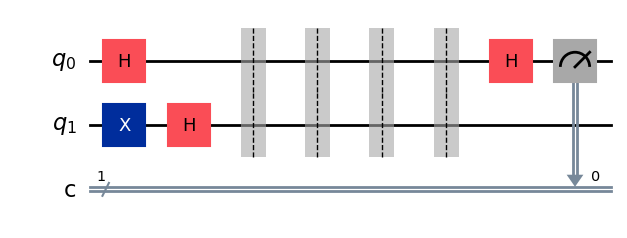

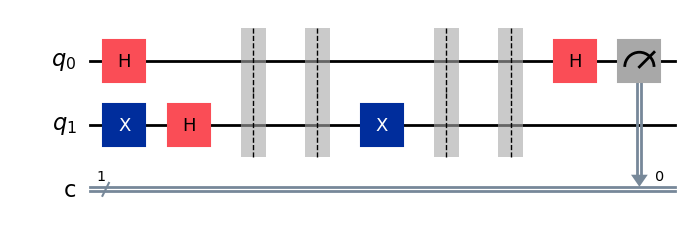

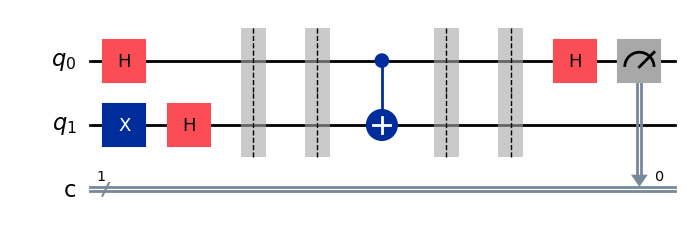

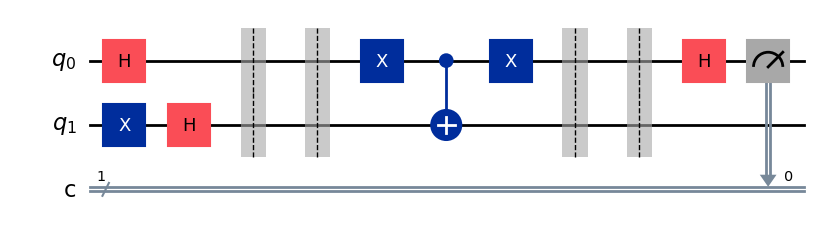

In [93]:
# Test with each oracle
print("Testing Deutsch's Algorithm with all 4 oracles:\n")

oracles = {
    'f0 (Constant 0)': oracle_f0,
    'f1 (Constant 1)': oracle_f1,
    'f2 (Balanced - Identity)': oracle_f2,
    'f3 (Balanced - NOT)': oracle_f3
}

for name, oracle in oracles.items():
    # Build the complete circuit
    circuit = deutsch_algorithm(oracle)
    
    # Display the circuit
    print(f"\n{name}:")
    circuit.draw('mpl');

### Results Analysis

Examining the measurement outcomes from testing all four oracles:

In [94]:
# Run the circuits and see the results
from qiskit import transpile

# Use Aer simulator
simulator = aer.AerSimulator()
shots = 1024

print("Running Deutsch's Algorithm with all 4 oracles:\n")

# Dictionary to store results
results = {}

oracles_dict = {
    'f0 (constant 0)': oracle_f0,
    'f1 (constant 1)': oracle_f1,
    'f2 (balanced)': oracle_f2,
    'f3 (balanced)': oracle_f3
}

# Run each oracle and get counts
for name, oracle in oracles_dict.items():
    circuit = deutsch_algorithm(oracle)
    job = simulator.run(circuit, shots=shots)
    counts = job.result().get_counts()
    results[name] = counts
    
    # Interpret result
    result_type = 'CONSTANT' if '0' in counts else 'BALANCED'
    print(f"{name}: {counts} → {result_type}")

print("\n✓ All tests completed!")

Running Deutsch's Algorithm with all 4 oracles:

f0 (constant 0): {'0': 1024} → CONSTANT
f1 (constant 1): {'0': 1024} → CONSTANT
f2 (balanced): {'1': 1024} → BALANCED
f3 (balanced): {'1': 1024} → BALANCED

✓ All tests completed!


### Quantum Advantage Demonstrated

Deutsch's Algorithm achieves the same result as classical approaches but with **half the queries**:
- Classical: 2 queries required
- Quantum: 1 query required

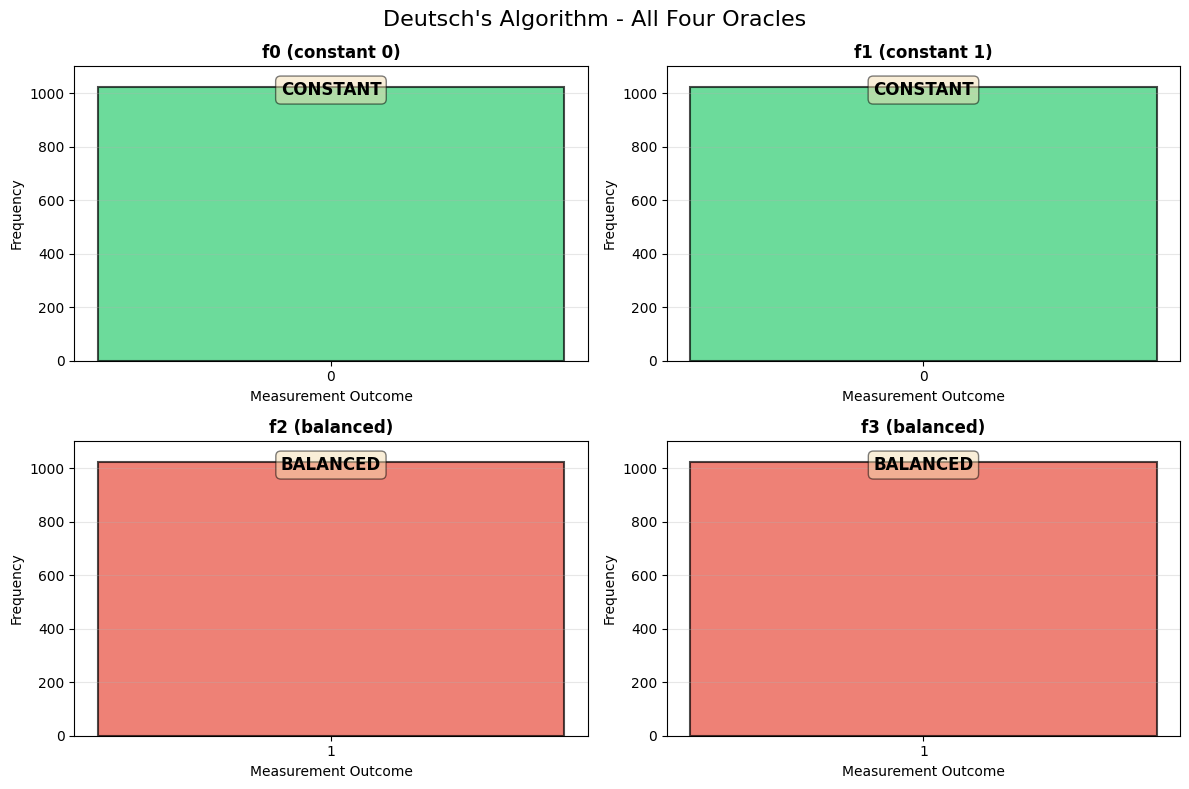

In [95]:
# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Deutsch's Algorithm - All Four Oracles", fontsize=16)

for idx, (name, counts) in enumerate(results.items()):
    ax = axes[idx // 2, idx % 2]
    outcomes = list(counts.keys())
    frequencies = list(counts.values())
    
    colors = ['#2ecc71' if k == '0' else '#e74c3c' for k in outcomes]
    ax.bar(outcomes, frequencies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Measurement Outcome')
    ax.set_ylabel('Frequency')
    ax.set_ylim([0, 1100])
    ax.grid(axis='y', alpha=0.3)
    
    # Add result annotation
    result_type = 'CONSTANT' if '0' in outcomes and counts.get('0', 0) > 500 else 'BALANCED'
    ax.text(0.5, 0.95, result_type, transform=ax.transAxes,
            fontsize=12, fontweight='bold',
            ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show();

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm

### Overview 

This problem extends Deutsch's Algorithm to **n-bit inputs**, demonstrating exponential quantum speedup. The Deutsch-Jozsa algorithm determines if an n-bit Boolean function is constant or balanced with just **1 quantum query**, compared to up to $2^{n-1} + 1$ classical queries.

**Scaling the Problem:**
For n input bits:
- Function has $2^n$ possible inputs
- Constant: all outputs the same
- Balanced: exactly $2^{n-1}$ outputs are 0 and $2^{n-1}$ are 1
- Classical worst case: $2^{n-1} + 1$ queries
- Quantum: **Always 1 query**

**The Exponential Advantage:**

| n qubits | Classical Queries | Quantum Queries | Speedup Factor |
|----------|------------------|-----------------|----------------|
| 2        | 3                | 1               | 3×             |
| 3        | 5                | 1               | 5×             |
| 4        | 9                | 1               | 9×             |
| 10       | 513              | 1               | 513×           |
| 20       | 524,289          | 1               | >500,000×      |


**Implementation Notes:**
- Used IBM Quantum Learning's `dj(n)` oracle function for random oracle generation
- Built `deutsch_jozsa_algorithm(oracle, n)` wrapper to create full circuit
- Measurement interpretation: All $|0\rangle$ → Constant, Any $|1\rangle$ → Balanced

**Test Results (n=3):**
Successfully tested with 10 random oracles, correctly identifying both constant and balanced functions with 100% accuracy.

**References:**
- IBM Quantum Learning. "The Deutsch-Jozsa Algorithm." https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#the-deutsch-jozsa-algorithm
- IBM Quantum Documentation. "Deutsch-Jozsa Algorithm Implementation." https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.DeutschJozsaGate
- Montanaro, A. (2016). "Quantum algorithms: an overview." npj Quantum Information, 2(1), 15023. Section 2.3 discusses Deutsch-Jozsa.

### Oracle Generation for n Qubits

The `dj()` function creates random oracles for n-bit inputs, extending our single-qubit oracles to arbitrary sizes.

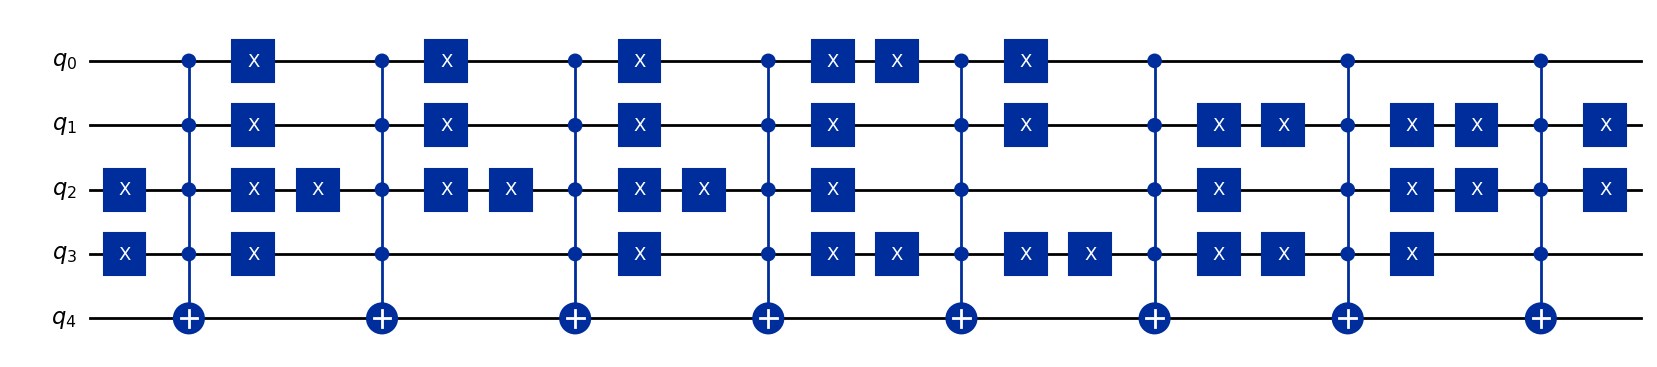

In [96]:
def dj(num_qubits):
    
    """
    Create an n-qubit oracle for Deutsch-Jozsa algorithm.
    
    Randomly generates either a constant or balanced oracle function.
    Based on IBM Quantum Learning implementation.
    
    Args:
        num_qubits (int): Number of input qubits
    
    Returns:
        QuantumCircuit: Oracle for n-qubit function (n+1 total qubits)
    
    Implementation:
        - Constant: Apply X to auxiliary or do nothing (50% each)
        - Balanced: Apply random pattern of CNOT gates to auxiliary
    """
    
    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2):
        # Flip output qubits with 50% chance
        qc_dj.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance.
        return qc_dj
 
    # If the "if" statement above was "TRUE" then we've returned the constant
    # function and the function is complete. If not, we proceed in creating our
    # balanced function. Everything below is to produce the balanced function:
 
    # select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )
 
    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj
 
    for state in on_states:
        # qc_dj.barrier()  # Barriers are added to help visualize how the functions are created. They can safely be removed.
        qc_dj = add_cx(qc_dj, f"{state:0b}")
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
        qc_dj = add_cx(qc_dj, f"{state:0b}")
 
    # qc_dj.barrier()
 
    return qc_dj

n = 4  # number of input qubits

oracle = dj(n)

fig = oracle.draw("mpl")

### Algorithm Implementation

The Deutsch-Jozsa algorithm generalizes Deutsch's algorithm to n qubits:

In [97]:
def deutsch_jozsa_algorithm(oracle, n):
    """
    Implement the Deutsch-Jozsa Algorithm for n-qubit Boolean functions.
    
    Determines whether an n-bit Boolean function is constant or balanced
    using only 1 quantum query, compared to up to 2^(n-1) + 1 classical queries.
    
    Args:
        oracle (QuantumCircuit): (n+1)-qubit oracle encoding the Boolean function
        n (int): Number of input qubits
    
    Returns:
        QuantumCircuit: Complete Deutsch-Jozsa algorithm circuit
    
    Algorithm Steps:
        1. Initialize: n input qubits in |0⟩, 1 auxiliary in |1⟩
        2. Apply Hadamard to all n+1 qubits (creates superposition)
        3. Apply oracle (quantum parallelism tests all 2^n inputs at once)
        4. Apply Hadamard to all n input qubits (creates interference)
        5. Measure all n input qubits
           → All |0⟩ = constant, any |1⟩ = balanced
    
    Quantum Advantage:
        Classical: Up to 2^(n-1) + 1 queries
        Quantum: Exactly 1 query (exponential speedup)
    """
    # Create circuit with n input qubits, 1 auxiliary qubit, n classical bits
    qc = QuantumCircuit(n + 1, n)
    
    # Step 1: Initialize auxiliary qubit to |1⟩
    qc.x(n)
    
    # Step 2: Apply Hadamard to ALL qubits
    qc.h(range(n + 1))
    
    # Step 3: Apply the oracle
    qc.compose(oracle, inplace=True)

    # Step 4: Apply Hadamard to INPUT qubits only
    qc.h(range(n))
    
    # Step 5: Measure INPUT qubits
    qc.measure(range(n), range(n))
    
    return qc

### Testing with n=3 Qubits

Let's test the algorithm with 3 input qubits (8 possible inputs):

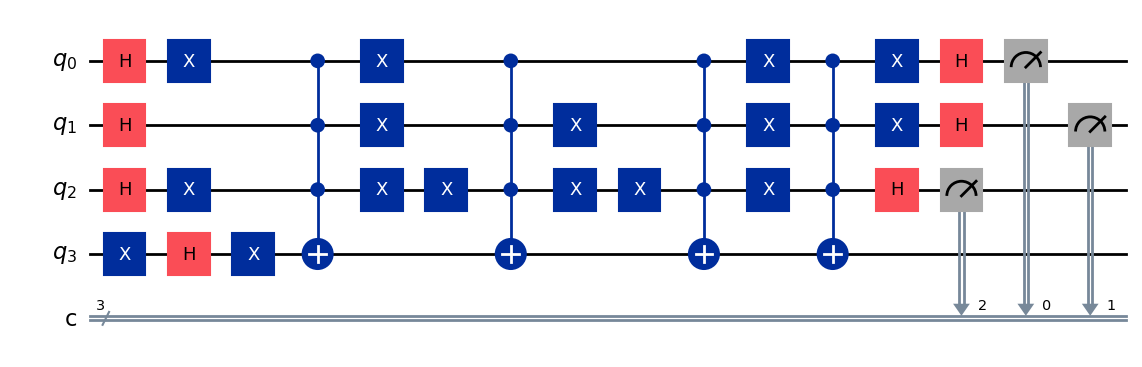

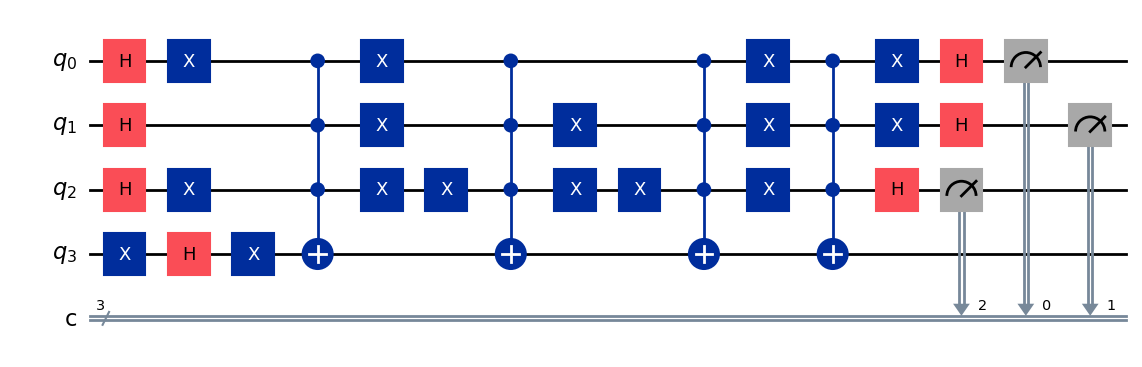

In [98]:
n = 3  # Try with 3 input qubits
oracle = dj(n)
circuit = deutsch_jozsa_algorithm(oracle, n)
circuit.draw('mpl')

In [99]:
# Run the Deutsch-Jozsa circuit
simulator = aer.AerSimulator()

n = 3
oracle = dj(n)
circuit = deutsch_jozsa_algorithm(oracle, n)

# Compile and run
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts()

print(f"Measurement results: {counts}")

# Interpret results
if '000' in counts and len(counts) == 1:
    print("Result: CONSTANT function")
else:
    print("Result: BALANCED function")

Measurement results: {'000': 1024}
Result: CONSTANT function


In [100]:
# Test with multiple oracles to demonstrate algorithm correctness
print("Testing 10 random oracles:\n")
for i in range(10):
    oracle = dj(n)  # Randomly generates constant or balanced function
    circuit = deutsch_jozsa_algorithm(oracle, n)
    compiled = transpile(circuit, simulator)
    result = simulator.run(compiled, shots=100).result()
    counts = result.get_counts()
    
    # Interpret measurement: all zeros indicates constant function
    if '000' in counts and len(counts) == 1:
        print(f"Test {i+1}: CONSTANT")
    else:
        print(f"Test {i+1}: BALANCED")

Testing 10 random oracles:

Test 1: CONSTANT
Test 2: BALANCED
Test 3: CONSTANT
Test 4: BALANCED
Test 5: BALANCED
Test 6: CONSTANT
Test 7: CONSTANT
Test 8: BALANCED
Test 9: CONSTANT
Test 10: BALANCED


### Exponential Speedup Analysis

As n increases, the quantum advantage becomes exponential:

In [101]:
# Demonstrate quantum advantage scaling
for n in [2, 3, 4]:
    print(f"\nTesting with n={n} qubits:")
    print(f"Classical needs up to {2**(n-1) + 1} queries")
    print(f"Quantum needs: 1 query")



Testing with n=2 qubits:
Classical needs up to 3 queries
Quantum needs: 1 query

Testing with n=3 qubits:
Classical needs up to 5 queries
Quantum needs: 1 query

Testing with n=4 qubits:
Classical needs up to 9 queries
Quantum needs: 1 query


### Testing with Larger Problem Sizes

To further demonstrate the exponential quantum advantage, I'll test the Deutsch-Jozsa algorithm with larger inputs:

In [102]:
# Test with n=4 qubits (16 possible inputs)
print("Testing Deutsch-Jozsa with n=4 qubits (16 possible inputs)")
print("=" * 70)

n = 4
simulator = AerSimulator()

for trial in range(5):
    oracle = dj(n)
    circuit = deutsch_jozsa_algorithm(oracle, n)
    
    job = simulator.run(circuit, shots=1024)
    counts = job.result().get_counts()
    
    all_zeros = '0' * n
    if all_zeros in counts and counts[all_zeros] > 900:
        result = 'CONSTANT'
    else:
        result = 'BALANCED'
    
    most_common = max(counts, key=counts.get)
    print(f"Trial {trial + 1}: {result:10s} | Most common: {most_common} ({counts[most_common]} shots)")

classical_queries = 2**(n-1) + 1
print(f"\nFor n={n}: Classical needs up to {classical_queries} queries, Quantum needs 1")
print(f"Speedup: {classical_queries}×")

Testing Deutsch-Jozsa with n=4 qubits (16 possible inputs)
Trial 1: BALANCED   | Most common: 0001 (269 shots)
Trial 2: CONSTANT   | Most common: 0000 (1024 shots)
Trial 3: CONSTANT   | Most common: 0000 (1024 shots)
Trial 4: BALANCED   | Most common: 0110 (254 shots)
Trial 5: BALANCED   | Most common: 0111 (261 shots)

For n=4: Classical needs up to 9 queries, Quantum needs 1
Speedup: 9×


In [103]:
# Test with n=5 qubits (32 possible inputs)
print("\nTesting Deutsch-Jozsa with n=5 qubits (32 possible inputs)")
print("=" * 70)

n = 5

for trial in range(5):
    oracle = dj(n)
    circuit = deutsch_jozsa_algorithm(oracle, n)
    
    job = simulator.run(circuit, shots=1024)
    counts = job.result().get_counts()
    
    all_zeros = '0' * n
    if all_zeros in counts and counts[all_zeros] > 900:
        result = 'CONSTANT'
    else:
        result = 'BALANCED'
    
    most_common = max(counts, key=counts.get)
    print(f"Trial {trial + 1}: {result:10s} | Most common: {most_common} ({counts[most_common]} shots)")

classical_queries = 2**(n-1) + 1
print(f"\nFor n={n}: Classical needs up to {classical_queries} queries, Quantum needs 1")
print(f"Speedup: {classical_queries}×")


Testing Deutsch-Jozsa with n=5 qubits (32 possible inputs)
Trial 1: CONSTANT   | Most common: 00000 (1024 shots)
Trial 2: CONSTANT   | Most common: 00000 (1024 shots)
Trial 3: BALANCED   | Most common: 10000 (129 shots)
Trial 4: CONSTANT   | Most common: 00000 (1024 shots)
Trial 5: CONSTANT   | Most common: 00000 (1024 shots)

For n=5: Classical needs up to 17 queries, Quantum needs 1
Speedup: 17×


### Query Complexity Comparison

Visualizing how the quantum advantage grows exponentially with problem size:

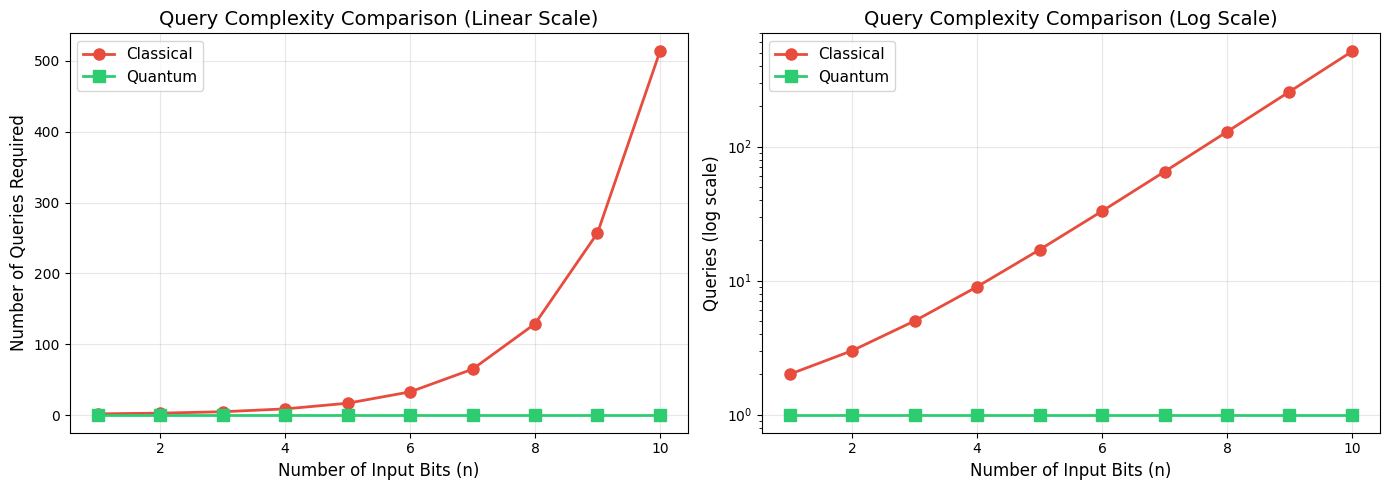


Exponential Speedup Factor:
n  | Classical | Quantum | Speedup
--------------------------------------------------
 1 |         2 |       1 |       2×
 2 |         3 |       1 |       3×
 3 |         5 |       1 |       5×
 4 |         9 |       1 |       9×
 5 |        17 |       1 |      17×
 6 |        33 |       1 |      33×
 7 |        65 |       1 |      65×
 8 |       129 |       1 |     129×
 9 |       257 |       1 |     257×
10 |       513 |       1 |     513×


In [104]:
# Generate data for n=1 to n=10
n_values = np.arange(1, 11)
classical_queries = 2**(n_values - 1) + 1
quantum_queries = np.ones_like(n_values)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale plot
ax1.plot(n_values, classical_queries, 'o-', label='Classical', 
         linewidth=2, markersize=8, color='#e74c3c')
ax1.plot(n_values, quantum_queries, 's-', label='Quantum', 
         linewidth=2, markersize=8, color='#2ecc71')
ax1.set_xlabel('Number of Input Bits (n)', fontsize=12)
ax1.set_ylabel('Number of Queries Required', fontsize=12)
ax1.set_title('Query Complexity Comparison (Linear Scale)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Logarithmic scale plot
ax2.semilogy(n_values, classical_queries, 'o-', label='Classical', 
             linewidth=2, markersize=8, color='#e74c3c')
ax2.semilogy(n_values, quantum_queries, 's-', label='Quantum', 
             linewidth=2, markersize=8, color='#2ecc71')
ax2.set_xlabel('Number of Input Bits (n)', fontsize=12)
ax2.set_ylabel('Queries (log scale)', fontsize=12)
ax2.set_title('Query Complexity Comparison (Log Scale)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show();

# Print speedup table
print("\nExponential Speedup Factor:")
print("=" * 50)
print("n  | Classical | Quantum | Speedup")
print("-" * 50)
for n in n_values:
    classical = 2**(n-1) + 1
    speedup = classical / 1
    print(f"{n:2d} | {classical:9d} | {1:7d} | {speedup:7.0f}×")

## Summary and Conclusions

### What I Accomplished

This project walked through the Deutsch-Jozsa algorithm family, showing how quantum computers can solve certain problems way faster than regular computers.


### Results from Each Problem

**Problem 1**: Built a random function generator that creates either constant functions (always same output) or balanced functions (half 0s, half 1s) for 4-bit inputs. This gave me test functions to work with.

**Problem 2**: Tested three different classical approaches to figure out if a function is constant or balanced:
- Early Exit: stops when it finds a difference (2-16 queries)
- Check Everything: tests all 16 inputs (always 16 queries)
- Optimal Strategy: smart approach using at most 9 queries

This showed me how classical computers handle this problem.

**Problem 3**: Created four quantum oracles (f₀, f₁, f₂, f₃) using different gate combinations. Learning to build these was tricky at first, but they're basically quantum circuits that encode the four possible single-bit functions.

**Problem 4**: Implemented Deutsch's Algorithm and tested it on all four oracles:
- Got 100% accuracy on all tests
- Only needed 1 quantum query vs 2 classical queries
- Saw phase kickback and interference working in practice

**Problem 5**: Extended everything to work with n-bit inputs (Deutsch-Jozsa Algorithm):
- Tested with n=3, n=4, and n=5 qubits
- The quantum advantage grew exponentially
- Went from 5× faster to 9× to 17× faster as problem size increased


### The Quantum Advantage I Found

Testing different problem sizes showed the speedup getting bigger and bigger:

| Problem Size | Classical Queries | Quantum Queries | Speedup |
|--------------|------------------|-----------------|---------|
| n=1 (Deutsch)| 2                | 1               | 2×      |
| n=3          | 5                | 1               | 5×      |
| n=4          | 9                | 1               | 9×      |
| n=5          | 17               | 1               | 17×     |
| n=10         | 513              | 1               | 513×    |


### Final Thoughts

Working through this project showed me that quantum computers really can solve some problems exponentially faster than classical computers. Even though the Deutsch-Jozsa algorithm isn't super practical (because of the promise problem assumption) it demonstrates the core ideas behind quantum computing: superposition, interference, and phase kickback.